# infer.py 推理脚本

## 1. 推理脚本是什么

**训练** = 让模型从数据中学习，调整内部参数（权重），是一个反复迭代的过程。
**推理（Inference）** = 用训练好的模型对新数据进行预测，参数固定不变，只做一次前向传播。

| 对比维度           | 训练                    | 推理                   |
| ------------------ | ----------------------- | ---------------------- |
| 参数是否更新       | 是（反向传播 + 优化器） | 否（固定权重）         |
| 需要标签（答案）吗 | 需要（计算损失）        | 不需要                 |
| 速度               | 慢                      | 快                     |
| 内存               | 多（需存梯度）          | 少（no_grad 关掉梯度） |
| 典型场景           | 跑训练代码              | 用模型预测自己的图片   |

**推理脚本（infer.py）解决的问题：**

训练结束后，你得到了一个权重文件（`mnist_cnn.pth`）。
`infer.py` 的作用就是：**加载这个权重，对任意一张新图片给出预测结果**，不需要重新打开 Jupyter，不需要运行完整训练代码。

## 2. 整体运行流程图

```
你提供一张图片（手机拍的手写数字）
          │
          ▼
┌─────────────────────────────┐
│    preprocess_image()       │
│  1. 转灰度                  │
│  2. 智能翻转（白底→黑底）    │
│  3. Otsu 阈值去除背景噪点   │
│  4. 裁剪出数字区域           │
│  5. 缩放到 20×20            │
│  6. 放进 28×28 画布正中央   │
└─────────────────────────────┘
          │
          ▼  28×28 灰度图
┌─────────────────────────────┐
│    transforms（标准化）      │
│  ToTensor() + Normalize()   │
│  shape: [1, 1, 28, 28]      │
└─────────────────────────────┘
          │
          ▼  Tensor
┌─────────────────────────────┐
│       CNN 模型前向传播       │
│  Conv→BN→ReLU→Pool          │
│  Conv→BN→ReLU→Pool          │
│  Flatten→Linear→BN→ReLU    │
│  Dropout→Linear             │
│  输出: [1, 10] 的 logits    │
└─────────────────────────────┘
          │
          ▼
┌─────────────────────────────┐
│       Softmax               │
│  logits → 概率分布          │
│  10个数，加起来 = 1          │
└─────────────────────────────┘
          │
          ▼
    argmax() → 预测数字 + 可视化输出
```

---

## 3.调包

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import argparse
import matplotlib.pyplot as plt
from PIL import Image
from torch import dtype
from torch.utils.tensorboard.summary import histogram
from torchvision import transforms

## 4. 第一部分：模型定义 CNN

In [2]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.net=nn.Sequential(
            nn.Conv2d(1,32,kernel_size=3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64*7*7,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128,10)
        )

    def forward(self,x):
        return self.net(x)

### 为什么推理脚本里也要定义模型？

你保存的 `mnist_cnn.pth` 文件只存了**参数的数值**（权重矩阵），没有存网络的结构。
就像一份考卷只有答案数字，没有题目——你必须先有题目（模型结构），才能把答案填进去。

所以推理脚本里的 `CNN` 类必须和训练时**完全一样**，一个层都不能差。

### 数据在模型里的形状变化

```
输入:  [1, 1, 28, 28]   ← [batch, 通道, 高, 宽]

Conv2d(1→32)  → [1, 32, 28, 28]   ← 提取32种特征，尺寸不变(padding=1)
MaxPool2d     → [1, 32, 14, 14]   ← 宽高各减半

Conv2d(32→64) → [1, 64, 14, 14]   ← 提取64种特征，尺寸不变
MaxPool2d     → [1, 64,  7,  7]   ← 宽高各减半

Flatten       → [1, 3136]          ← 64×7×7 = 3136，展平成一维
Linear(3136→128) → [1, 128]
Linear(128→10)   → [1, 10]         ← 10个数字类别的原始分数
```

### BatchNorm 和 Dropout 在推理时的行为

这两个层在训练和推理时**行为不同**，这就是为什么推理时必须调用 `model.eval()`：

| 层           | 训练模式 (model.train()) | 推理模式 (model.eval()) |
| ------------ | ------------------------ | ----------------------- |
| Dropout(0.5) | 随机丢弃 50% 神经元      | 全部保留（等比缩放）    |
| BatchNorm    | 用当前批次统计           | 用训练时积累的均值/方差 |

如果推理时忘记调 `eval()`，每次预测结果可能都不一样（因为 Dropout 随机性）。

---

##

## 5. 第二部分：Otsu(大津算法) 自适应阈值

In [3]:
def otsu(arr):
    hist,_=np.histogram(arr.flatten(),bins=256,range=(0,256))
    hist=hist.astype(float)
    total=hist.sum()
    sum_total=np.dot(np.arange(256),hist)
    best_thresh,best_val=0,0
    sum_bg,weight_bg=0.0,0.0

    for t in range(256):
        weight_bg+=hist[t]
        if weight_bg==0 or weight_bg==total:
            continue
        weight_fg=total-weight_bg
        sum_bg+=t*hist[t]
        mean_bg=sum_bg/weight_bg
        mean_fg=(sum_total-sum_bg)/weight_fg
        var=weight_fg*weight_bg*(mean_bg-mean_fg)**2
        if var>best_val:
            best_val,best_thresh=var,t

    return best_thresh

这是大津算法的核心公式：
类间方差 = 背景权重 × 前景权重 × (背景均值 - 前景均值)²

该值越大，说明背景和前景的差异越大，分离效果越好。

### 为什么需要阈值？

你的图片是手机拍的，有背景噪点、纸张纹理、光影等干扰。
模型只认识"干净的黑底白字图"，所以需要先把背景压成纯黑，保留笔画。

**阈值的作用**：亮度低于阈值的像素 → 变成 0（纯黑），高于阈值的 → 保留。

### 为什么不用固定阈值，而用 Otsu？

```
用马克笔拍照：笔画最亮 ≈ 240，背景噪点 ≈ 30  → 固定阈值50 刚好
用铅笔拍照：  笔画最亮 ≈ 120，背景噪点 ≈ 20  → 固定阈值50 会把大半笔画抹掉！
光线很暗：    笔画最亮 ≈ 90                    → 固定阈值50 只剩一点残影
```

Otsu 算法会自动分析这张图的像素分布，找到最佳分割点，不受光照影响。

### Otsu 算法原理（直觉版）

**目标**：找一个阈值 `t`，把像素分成"背景"（暗）和"笔画"（亮）两组，使两组**尽可能泾渭分明**。

用"组间方差"衡量分得好不好：

- 组间方差大 → 两组均值差得远 → 分得好
- 组间方差小 → 两组混在一起 → 分得差

```
公式：var(t) = weight_bg × weight_fg × (mean_bg - mean_fg)²

穷举 t 从 0 到 255，找让 var(t) 最大的那个 t
```

**像素直方图示意**（横轴=亮度，纵轴=像素数量）：

```
数量
 │  ████                         ████
 │  ████      ← Otsu 找谷底 →     ████
 │  ████                         ████
 └──────────────────────────────────── 亮度
   0(黑)   阈值t                 255(白)
  背景像素                       笔画像素
```


## 6. 第三部分：图像预处理 preprocess_image

In [4]:
def preprocess_image(image_path):
    img=Image.open(image_path).convert('L')
    arr=np.array(img,dtype=np.float32)

    if arr.mean()>127:     #确保是黑底白字（和 MNIST 一致）
        arr=255.0-arr

    thresh=otsu(arr)
    arr=np.where(arr>thresh,arr,0.0)       #np.where(条件, 值A, 值B)

    rows=np.any(arr>0,axis=1)       #布尔数组
    cols=np.any(arr>0,axis=0)

    if not rows.any():
        return Image.fromarray(np.zeros((28,28),dtype=np.uint8))    #从np转换为图片

    r_min,r_max=np.where(rows)[0][[0,-1]]
    c_min,c_max=np.where(cols)[0][[0,-1]]

    h=r_max-r_min+1
    w=c_max-c_min+1
    pad=int(max(h,w)*0.2)
    r_min=max(0,r_min-pad)
    r_max=min(arr.shape[0]-1,r_max+pad)
    c_min=max(0,c_min-pad)
    c_max=min(arr.shape[1]-1,c_max+pad)
    cropped=arr[r_min:r_max+1,c_min:c_max+1]        #按新的边界裁剪出来

    h,w=cropped.shape       # 补全为正方形，并缩放到20x20
    if h>w:
        right=(h-w)//2
        left=(h-w)-right
        cropped=np.pad(cropped,((0,0),(right,left)))    #填充
    elif h<w:
        top=(w-h)//2
        bottom=(w-h)-top
        cropped=np.pad(cropped,((top,bottom),(0,0)))
    pil_20=Image.fromarray(cropped.astype(np.uint8)).resize((20,20),Image.Resampling.LANCZOS)   # 缩放

    canvas=np.zeros((28,28),dtype=np.uint8)     #嵌入 28×28 画布正中间
    canvas[4:24,4:24]=np.array(pil_20)

    return Image.fromarray(canvas)

这个函数把"任意手机拍摄的图片"转成"MNIST 格式的 28×28 灰度图"。

### 步骤 1：转灰度

```python
img = Image.open(image_path).convert('L')
```

`'L'` 是 PIL 的灰度模式，把 RGB 三通道图片转成单通道。
每个像素变成一个 0~255 的数（0=纯黑，255=纯白）。

为什么要转灰度？因为 MNIST 数据集就是灰度图，模型只有1个输入通道，不接受彩色图。

### 步骤 2：智能翻转（黑白颠倒）

```python
if arr.mean() > 127:
    arr = 255.0 - arr
```

MNIST 数据集的格式是**黑底白字**（背景=0，笔画≈255）。
但你手写后拍照，通常是**白纸黑字**（背景≈255，笔画≈0）。

判断逻辑：如果整张图的平均亮度 > 127，说明大部分是亮色（白纸），就翻转颜色。

```
翻转前（白纸黑字）：背景=230, 笔画=30
翻转后（黑底白字）：背景=25,  笔画=225   ← 符合 MNIST 格式
```

### 步骤 3：Otsu 去除背景噪点

```python
thresh = _otsu_threshold(arr)
arr = np.where(arr > thresh, arr, 0.0)
```

`np.where(条件, 满足时的值, 不满足时的值)`
这里：亮度 > thresh 的像素保留原值，其余变成 0（纯黑）。

结果：背景噪点全部变成纯黑，笔画保留。

### 步骤 4：裁剪数字区域（Bounding Box）

```python
rows = np.any(arr > 0, axis=1)   # 每行是否有非零像素
cols = np.any(arr > 0, axis=0)   # 每列是否有非零像素
r_min, r_max = np.where(rows)[0][[0, -1]]   # 有像素的最小/最大行
c_min, c_max = np.where(cols)[0][[0, -1]]   # 有像素的最小/最大列
```

**目的**：找到数字的最小外接矩形，把数字从大图里裁出来。

```
原图（500×500）：
┌─────────────────────────┐
│                         │
│       ┌──────┐          │
│       │  7   │  ← 找到这个区域
│       └──────┘          │
│                         │
└─────────────────────────┘
裁剪后只保留数字那块区域。
```

### 步骤 5：加留白

```python
pad = int(max(h, w) * 0.2)
r_min = max(0, r_min - pad)
...
```

MNIST 里的数字不是顶格写的，周围有一定空白。
这里在裁剪区域四周加 20% 的空白，让风格更接近 MNIST。

### 步骤 6：补齐为正方形

```python
if h > w:
    left = (h - w) // 2
    right = (h - w) - left
    cropped = np.pad(cropped, ((0, 0), (left, right)))
```

你写的"1"可能很细长（高 > 宽），"0"可能接近正方形。
为了统一缩放到 20×20，先把矩形补成正方形（补的是纯黑像素）。

### 步骤 7：缩放 + 放入 28×28 画布

```python
pil_20 = Image.fromarray(...).resize((20, 20), Image.LANCZOS)
canvas = np.zeros((28, 28), dtype=np.uint8)
canvas[4:24, 4:24] = np.array(pil_20)
```

MNIST 的规范格式是：

- 整体 28×28
- 数字内容在中间 20×20 的区域
- 四周各留 4 像素的黑边

`canvas[4:24, 4:24]` 就是把 20×20 的数字放在 28×28 画布的正中央。

## 7. 第四部分：推理主函数 predict_image

In [5]:
def predict_image(image_path,model,device,save_path='prediction_result.png'):
    img_processed=preprocess_image(image_path)

    transform_infer=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,),(0.3081,))
    ])

    tensor=transform_infer(img_processed).unsqueeze(0).to(device)

    model.eval()        # 推理
    with torch.no_grad():
        logits=model(tensor)
        probs_np=F.softmax(logits,dim=1).squeeze().cpu().numpy()
        predicted=int(probs_np.argmax())        # 最大值索引，非最大值

    # 可视化
    original=Image.open(image_path).convert('L')
    fig,axes=plt.subplots(1,3,figsize=(14,4))
    axes[0].imshow(original,cmap='gray')
    axes[0].set_title('Original',fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(img_processed,cmap='gray')
    axes[1].set_title(f'Model Input (28x28)\nPredicted: {predicted}  ({probs_np[predicted] * 100:.1f}%)',fontsize=12)
    axes[1].axis('off')

    colors = ['#4C72B0'] * 10          # 默认蓝色
    colors[predicted] = '#DD4444'      # 预测的那个柱子变红色
    bars = axes[2].bar(range(10), probs_np * 100, color=colors,edgecolor='white', linewidth=0.5)

    axes[2].set_xticks(range(10))
    axes[2].set_xlabel('Digit Class', fontsize=11)
    axes[2].set_ylabel('Probability (%)', fontsize=11)
    axes[2].set_title('Probability Distribution', fontsize=13)
    axes[2].set_ylim(0, 115)     # 给百分比标签留空间
    axes[2].yaxis.grid(True, linestyle='--', alpha=0.5)
    axes[2].set_axisbelow(True)  # 网格线放在柱子后面

    for bar, p in zip(bars, probs_np):
        if p > 0.005:   # 只标概率大于 0.5% 的，避免太多 0% 乱糟糟
          axes[2].text(
              bar.get_x() + bar.get_width() / 2,   # 柱子中央水平位置
              bar.get_height() + 1,                # 柱子顶端略高一点
              f'{p * 100:.1f}%',
              ha='center', va='bottom', fontsize=9
            )

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    # 命令行输出概率分布（文字版条形图）
    print(f'\nPredicted: {predicted}   Confidence: {probs_np[predicted] * 100:.2f}%')
    print('All probabilities:')
    for i, p in enumerate(probs_np):
        bar_str = '█' * int(p * 40)    # 用 Unicode 方块画水平条形图
        print(f'  {i}: {bar_str} {p * 100:.2f}%')

    return predicted, probs_np

```python
def predict_image(image_path, model, device, save_path='prediction_result.png'):
```

这个函数把预处理、推理、可视化三件事串起来。

### 7.1 转成模型能接受的格式

```python
transform_infer = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
tensor = transform_infer(img_processed).unsqueeze(0).to(device)
```

**ToTensor()**：PIL Image → PyTorch Tensor，形状 `[1, 28, 28]`，值域 0~1
**Normalize()**：标准化，公式 `(x - 0.1307) / 0.3081`
**unsqueeze(0)**：增加 batch 维度，`[1, 28, 28]` → `[1, 1, 28, 28]`（1张图的batch）
**.to(device)**：把数据挪到和模型同一个设备（CPU 或 GPU）

为什么要 `unsqueeze`？
模型训练时每次输入是一批图片 `[64, 1, 28, 28]`，单张图片也需要保持这个格式，所以在最前面加一个 batch 维度，变成 `[1, 1, 28, 28]`（batch_size=1）。

### 7.2 推理

```python
model.eval()
with torch.no_grad():
    logits = model(tensor)
    probs_np = F.softmax(logits, dim=1).squeeze().cpu().numpy()
```

**model.eval()**：切换到推理模式（关闭 Dropout，BatchNorm 用固定统计量）

**torch.no_grad()**：关闭梯度计算
推理时不需要反向传播，关掉梯度追踪可以：

- 节省约一半内存
- 加快计算速度

**logits**：模型输出的10个原始分数，形状 `[1, 10]`
示例：`[[-2.3, 8.1, 0.5, -1.2, 0.1, -0.8, 0.3, 15.2, -0.4, 0.9]]`

**F.softmax(logits, dim=1)**：把10个分数转成概率分布
公式：`prob[i] = exp(logit[i]) / sum(exp(logit[j]))`
特性：所有概率加起来 = 1，每个值在 0~1 之间
示例：`[[0.001, 0.01, ..., 0.95, ...]]` → 最大的那个对应预测类别

**squeeze()**：去掉 batch 维度，`[1, 10]` → `[10]`
**.cpu()**：如果用了 GPU，把数据移回 CPU（numpy 不支持 GPU Tensor）
**.numpy()**：转成 numpy 数组，方便后续计算和绘图

**predicted = int(probs_np.argmax())**：找概率最大的下标，就是预测的数字

### 7.3 可视化

```python
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
```

创建一行三列的图表框架，输出三张图：

| 第1张        | 第2张                 | 第3张                |
| ------------ | --------------------- | -------------------- |
| 原始图片     | 模型实际看到的28×28图 | 10个类别的概率柱状图 |
| 用于肉眼对比 | **最重要的调试图**    | 看置信度和第二名差距 |

**第2张图为什么最重要？**
它显示的是模型的实际输入，如果这张图看起来很奇怪（全是噪点、数字变形、缺笔画），说明问题在预处理而不是模型。

```python
colors = ['#4C72B0'] * 10
colors[predicted] = '#DD4444'   # 预测的那个柱子变红
```

---

## 8. 第五部分：使用

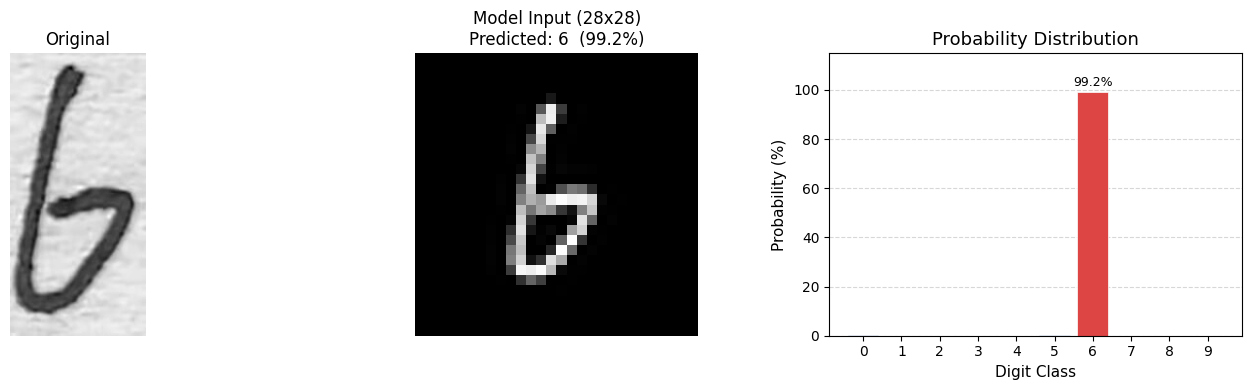


Predicted: 6   Confidence: 99.20%
All probabilities:
  0:  0.30%
  1:  0.01%
  2:  0.02%
  3:  0.00%
  4:  0.02%
  5:  0.38%
  6: ███████████████████████████████████████ 99.20%
  7:  0.00%
  8:  0.05%
  9:  0.01%


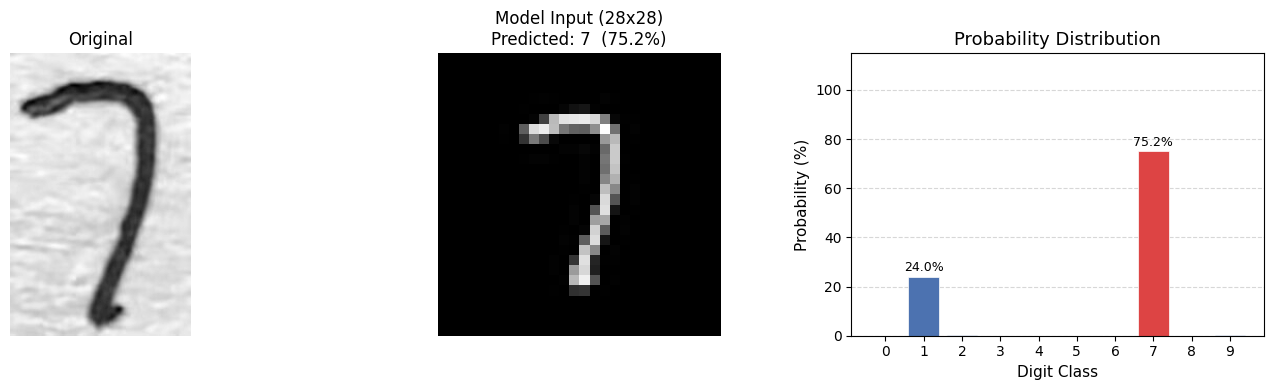


Predicted: 7   Confidence: 75.18%
All probabilities:
  0:  0.02%
  1: █████████ 24.01%
  2:  0.46%
  3:  0.07%
  4:  0.00%
  5:  0.01%
  6:  0.00%
  7: ██████████████████████████████ 75.18%
  8:  0.00%
  9:  0.24%


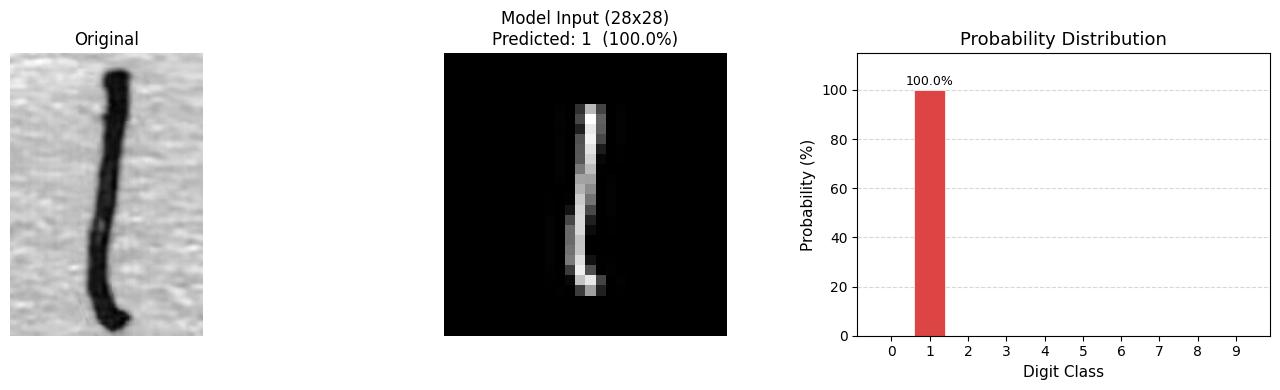


Predicted: 1   Confidence: 100.00%
All probabilities:
  0:  0.00%
  1: ███████████████████████████████████████ 100.00%
  2:  0.00%
  3:  0.00%
  4:  0.00%
  5:  0.00%
  6:  0.00%
  7:  0.00%
  8:  0.00%
  9:  0.00%


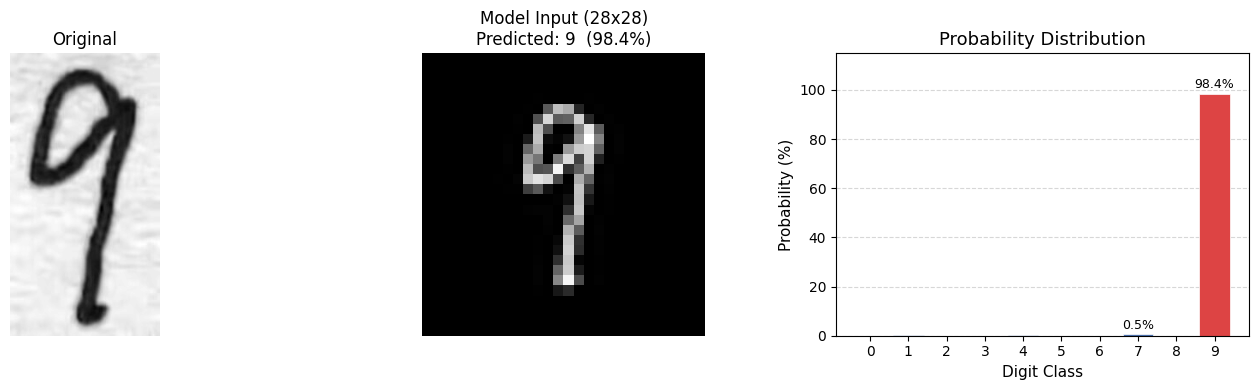


Predicted: 9   Confidence: 98.43%
All probabilities:
  0:  0.02%
  1:  0.41%
  2:  0.02%
  3:  0.05%
  4:  0.48%
  5:  0.01%
  6:  0.00%
  7:  0.54%
  8:  0.06%
  9: ███████████████████████████████████████ 98.43%


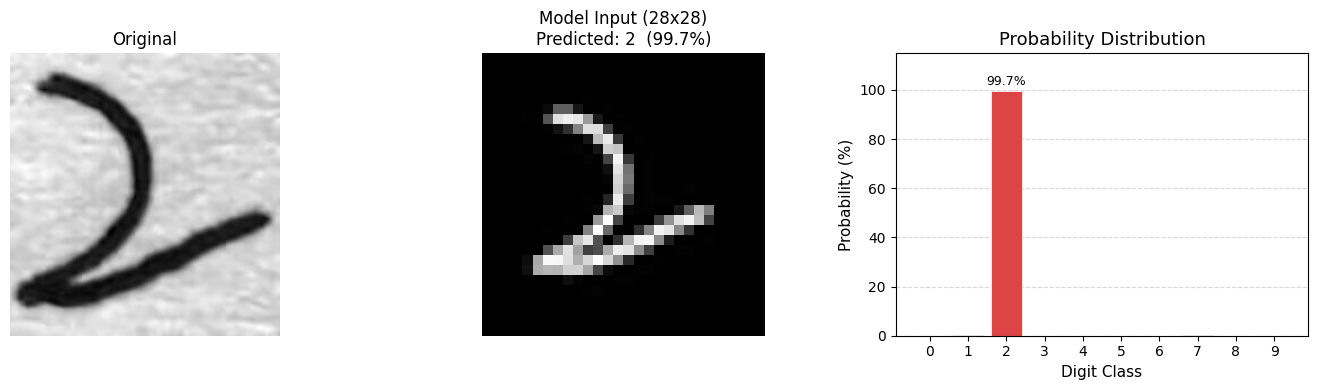


Predicted: 2   Confidence: 99.73%
All probabilities:
  0:  0.03%
  1:  0.12%
  2: ███████████████████████████████████████ 99.73%
  3:  0.00%
  4:  0.01%
  5:  0.00%
  6:  0.00%
  7:  0.10%
  8:  0.01%
  9:  0.00%


(2,
 array([2.9795920e-04, 1.1791614e-03, 9.9734479e-01, 2.9470515e-05,
        5.9373553e-05, 9.1876797e-07, 1.4378256e-05, 9.8082528e-04,
        7.5279575e-05, 1.7858190e-05], dtype=float32))

In [7]:
image_path1=r'028442e669b0c402d5c0cee7a97289af.jpg'
image_path2=r'1c71587ec9701370c84a6af3c6fbcb7f.jpg'
image_path3=r'7f00469beca0c36f2300ce9374820604.jpg'
image_path4=r'8ccc9f4433a2ab69dd0a6e0b1197f196.jpg'
image_path5=r'9879a277b88e10ea34ed54ad7438eae3.jpg'


device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model=CNN().to(device)
model.load_state_dict(torch.load('mnist_cnn.pth',map_location=device,weights_only=True))

predict_image(image_path1,model,device)
predict_image(image_path2,model,device)
predict_image(image_path3,model,device)
predict_image(image_path4,model,device)
predict_image(image_path5,model,device)
